In [14]:
# imports
import pandas as pd
import os

In [16]:
print("=== PHASE 0: DATASET DIAGNOSTICS ===")

fasta_path = '/kaggle/input/datasets/competitiveracist/uniprot/UP000005640_9606.fasta'
enriched_path = '/kaggle/input/datasets/competitiveracist/enriched-clinvar/massive_enriched_dataset.csv'
clinvar_path = '/kaggle/input/datasets/competitiveracist/clinvar-tab-delimited/variant_summary.txt'

# --- 1. FASTA Diagnostics ---
print("\n--- 1. FASTA FILE CHECK ---")
if os.path.exists(fasta_path):
    with open(fasta_path, 'r') as f:
        headers = []
        seq_count = 0
        for line in f:
            if line.startswith('>'):
                seq_count += 1
                if len(headers) < 3:
                    headers.append(line.strip())
                    
    print(f"Found FASTA file with {seq_count} protein sequences.")
    print("Top 3 Headers (Checking for 'GN=' format):")
    for h in headers:
        print(f"  {h}")
else:
    print("FASTA file not found at that path!")

# --- 2. Enriched CSV Diagnostics ---
print("\n--- 2. ENRICHED DATASET CHECK ---")
if os.path.exists(enriched_path):
    # Just load the first 5 rows to save memory
    df_enriched = pd.read_csv(enriched_path, nrows=5)
    print(f"Columns found: {list(df_enriched.columns)}")
    print("First Row Sample:")
    print(df_enriched.iloc[0].to_dict())
    
    # Get total length fast
    with open(enriched_path, 'r') as f:
        total_enriched = sum(1 for _ in f) - 1 # subtract header
    print(f"Total Rows: {total_enriched}")
else:
    print("Enriched dataset not found at that path!")

# --- 3. Raw ClinVar Diagnostics ---
print("\n--- 3. RAW CLINVAR CHECK ---")
if os.path.exists(clinvar_path):
    # variant_summary.txt is usually tab-delimited (\t)
    try:
        df_clinvar = pd.read_csv(clinvar_path, sep='\t', nrows=5, low_memory=False)
        print(f"Successfully read tab-delimited ClinVar.")
        print(f"Columns (First 15): {list(df_clinvar.columns)[:15]}")
        
        print("\nChecking 'Name' and 'GeneSymbol' columns for the first 2 rows:")
        if 'Name' in df_clinvar.columns and 'GeneSymbol' in df_clinvar.columns:
            print(df_clinvar[['Name', 'GeneSymbol']].head(2))
        else:
            print("WARNING: 'Name' or 'GeneSymbol' columns are missing!")
    except Exception as e:
        print(f"Failed to read ClinVar TXT. Error: {e}")
else:
    print("Raw ClinVar dataset not found at that path!")

=== PHASE 0: DATASET DIAGNOSTICS ===

--- 1. FASTA FILE CHECK ---
Found FASTA file with 20659 protein sequences.
Top 3 Headers (Checking for 'GN=' format):
  >sp|A0A0J9YXV3|GREP1_HUMAN Glycine-rich extracellular protein 1 OS=Homo sapiens OX=9606 GN=GREP1 PE=3 SV=1
  >sp|A6NGW2|STRCL_HUMAN Putative stereocilin-like protein OS=Homo sapiens OX=9606 GN=STRCP1 PE=5 SV=1
  >sp|A6NIY4|SPDE5_HUMAN Speedy protein E5 OS=Homo sapiens OX=9606 GN=SPDYE5 PE=3 SV=3

--- 2. ENRICHED DATASET CHECK ---
Columns found: ['Variant_ID', 'gnomAD_AF', 'SIFT_Score', 'CADD_Score', 'Is_Nonsense', 'Is_Missense', 'Is_Synonymous', 'Is_Splice_Site', 'Is_Pathogenic']
First Row Sample:
{'Variant_ID': '3:4418082:C:T', 'gnomAD_AF': 4.789e-06, 'SIFT_Score': 0.0, 'CADD_Score': 28.7, 'Is_Nonsense': 0, 'Is_Missense': 1, 'Is_Synonymous': 0, 'Is_Splice_Site': 0, 'Is_Pathogenic': 1}
Total Rows: 447459

--- 3. RAW CLINVAR CHECK ---
Successfully read tab-delimited ClinVar.
Columns (First 15): ['#AlleleID', 'Type', 'Name', 'GeneID

In [17]:
import pandas as pd
import re
import os
from tqdm import tqdm

print("=== PHASE 1: ALIGNING GENOMIC AND PROTEIN DATA ===")

FASTA_PATH = '/kaggle/input/datasets/competitiveracist/uniprot/UP000005640_9606.fasta'
ENRICHED_PATH = '/kaggle/input/datasets/competitiveracist/enriched-clinvar/massive_enriched_dataset.csv'
CLINVAR_PATH = '/kaggle/input/datasets/competitiveracist/clinvar-tab-delimited/variant_summary.txt'

# --- 1. Load the Enriched Dataset ---
print("1. Loading Enriched Dataset...")
df_enriched = pd.read_csv(ENRICHED_PATH)
print(f"   Starting variants: {len(df_enriched)}")

# --- 2. Load ClinVar Safely (Chunking to save RAM) ---
print("\n2. Parsing Raw ClinVar to extract Protein Names...")
# We only load the columns we absolutely need to save memory
usecols = ['Name', 'GeneSymbol', 'Assembly', 'Chromosome', 'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']

clinvar_chunks = []
# Reading in chunks of 100k rows
for chunk in tqdm(pd.read_csv(CLINVAR_PATH, sep='\t', usecols=usecols, chunksize=100000, low_memory=False)):
    # Keep only GRCh38 assembly to match standard genomic coordinates
    chunk = chunk[chunk['Assembly'] == 'GRCh38'].copy()
    chunk.dropna(subset=['Chromosome', 'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF'], inplace=True)
    
    # Clean up the chromosome column just in case it has 'chr' prefixes
    chunk['Chromosome'] = chunk['Chromosome'].astype(str).str.replace('chr', '')
    
    # Convert PositionVCF to int then str to prevent "4418082.0" float bugs
    chunk['PositionVCF'] = chunk['PositionVCF'].astype(int).astype(str)
    
    # Construct the master merge key!
    chunk['Variant_ID'] = chunk['Chromosome'] + ':' + chunk['PositionVCF'] + ':' + chunk['ReferenceAlleleVCF'] + ':' + chunk['AlternateAlleleVCF']
    
    clinvar_chunks.append(chunk[['Variant_ID', 'GeneSymbol', 'Name']])

df_clinvar = pd.concat(clinvar_chunks).drop_duplicates(subset=['Variant_ID'])
print(f"   ClinVar GRCh38 variants parsed: {len(df_clinvar)}")

# --- 3. The First Merge ---
print("\n3. Merging Enriched Scores with ClinVar Protein Names...")
master_df = df_enriched.merge(df_clinvar, on='Variant_ID', how='inner')
print(f"   Successful matches: {len(master_df)}")

# --- 4. Parse the Amino Acid Changes ---
print("\n4. Extracting strict Amino Acid mutations (p.Xxx123Yyy)...")
AA_MAP = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C', 'Gln': 'Q',
    'Glu': 'E', 'Gly': 'G', 'His': 'H', 'Ile': 'I', 'Leu': 'L', 'Lys': 'K',
    'Met': 'M', 'Phe': 'F', 'Pro': 'P', 'Ser': 'S', 'Thr': 'T', 'Trp': 'W',
    'Tyr': 'Y', 'Val': 'V', 'Ter': '*'
}

def parse_mutation(name):
    # This regex looks for standard missense/nonsense protein strings
    match = re.search(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2}|Ter)', str(name))
    if match:
        wt_aa = AA_MAP.get(match.group(1))
        pos = int(match.group(2))
        mut_aa = AA_MAP.get(match.group(3))
        return wt_aa, pos, mut_aa
    return None, None, None

master_df[['wt_aa', 'pos', 'mut_aa']] = master_df['Name'].apply(lambda x: pd.Series(parse_mutation(x)))
# Drop rows that aren't clean protein-altering mutations (e.g. intron variants)
master_df.dropna(subset=['wt_aa', 'pos', 'mut_aa'], inplace=True)
print(f"   Variants with clean protein mutations: {len(master_df)}")

# --- 5. Attach Raw Protein Sequences ---
print("\n5. Parsing UniProt FASTA for biological sequences...")
genes, sequences = [], []
with open(FASTA_PATH, 'r') as f:
    current_seq, current_gene = [], None
    for line in f:
        line = line.strip()
        if not line: continue
        if line.startswith('>'):
            if current_gene and current_seq:
                genes.append(current_gene)
                sequences.append("".join(current_seq))
            current_gene = line.split('GN=')[1].split()[0] if 'GN=' in line else None
            current_seq = []
        else:
            current_seq.append(line)
    if current_gene and current_seq:
        genes.append(current_gene)
        sequences.append("".join(current_seq))

uniprot_df = pd.DataFrame({'GeneSymbol': genes, 'Sequence': sequences}).drop_duplicates(subset=['GeneSymbol'])
final_df = master_df.merge(uniprot_df, on='GeneSymbol', how='inner')

# --- 6. The Biological Integrity Check ---
print("\n6. Running strict biological integrity check...")
def check_integrity(row):
    seq = row['Sequence']
    idx = int(row['pos']) - 1 # Sequence is 0-indexed, mutations are 1-indexed
    # Ensure the position exists, and the Wild-Type amino acid actually matches the FASTA
    if pd.notna(seq) and idx < len(seq):
        return seq[idx] == row['wt_aa']
    return False

final_df['is_valid'] = final_df.apply(check_integrity, axis=1)
valid_df = final_df[final_df['is_valid'] == True].copy()

# Save the ultimate dataset
output_file = '/kaggle/working/hybrid_ready_dataset.csv'
valid_df.to_csv(output_file, index=False)
print(f"\nPHASE 1 COMPLETE!")
print(f"Final fully-verified Hybrid Dataset size: {len(valid_df)} variants.")
print(f"Saved to: {output_file}")

=== PHASE 1: ALIGNING GENOMIC AND PROTEIN DATA ===
1. Loading Enriched Dataset...
   Starting variants: 447459

2. Parsing Raw ClinVar to extract Protein Names...


89it [01:09,  1.28it/s]


   ClinVar GRCh38 variants parsed: 4390583

3. Merging Enriched Scores with ClinVar Protein Names...
   Successful matches: 447459

4. Extracting strict Amino Acid mutations (p.Xxx123Yyy)...
   Variants with clean protein mutations: 143088

5. Parsing UniProt FASTA for biological sequences...

6. Running strict biological integrity check...

PHASE 1 COMPLETE!
Final fully-verified Hybrid Dataset size: 132739 variants.
Saved to: /kaggle/working/hybrid_ready_dataset.csv


In [18]:
import torch
from transformers import AutoTokenizer, EsmModel
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from tqdm import tqdm
import os
import gc

print("=== PHASE 2: MEGA-BATCH ESM-2 EMBEDDINGS ===")

# --- 1. Load the Model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Loading ESM-2 onto {device}...")
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = EsmModel.from_pretrained(MODEL_NAME).to(device)
model.eval() # CRITICAL: Turns off training mode

# --- 2. Optimized Dataset Class ---
class FastSequenceDataset(Dataset):
    def __init__(self, df):
        # We convert to lists for instant RAM access speed
        self.variant_ids = df['Variant_ID'].tolist()
        self.seqs = df['Sequence'].tolist()
        self.positions = df['pos'].tolist()
        self.mut_aas = df['mut_aa'].tolist()

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        # Perform the physical amino acid swap
        seq = list(self.seqs[idx])
        pos = int(self.positions[idx]) - 1 # 0-indexed
        
        # Safety check: ensure position is within the sequence length
        if pos < len(seq):
            seq[pos] = self.mut_aas[idx]
            
        mut_seq = "".join(seq)
        return self.variant_ids[idx], self.seqs[idx], mut_seq, pos

# --- 3. Load Your Clean Data ---
df = pd.read_csv('/kaggle/working/hybrid_ready_dataset.csv')
print(f"Total sequences to process: {len(df)}")

dataset = FastSequenceDataset(df)
# Batch size 64 is the sweet spot for Kaggle's T4 GPU with ESM-2 (1024 length)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# --- 4. The Processing Loop ---
master_embeddings = {} 

print("Generating 1D Sequence Embeddings...")
# torch.no_grad() is the magic that stops the VRAM from exploding
with torch.no_grad():
    for variant_ids, wt_seqs, mut_seqs, positions in tqdm(loader, desc="ESM-2 Processing"):
        
        # Tokenize (Truncate to max 1024 to prevent OOM errors on massive proteins)
        wt_tokens = tokenizer(wt_seqs, return_tensors="pt", padding=True, truncation=True, max_length=1024).to(device)
        mut_tokens = tokenizer(mut_seqs, return_tensors="pt", padding=True, truncation=True, max_length=1024).to(device)
        
        # Push through the model
        wt_out = model(**wt_tokens).last_hidden_state
        mut_out = model(**mut_tokens).last_hidden_state
        
        # Extract the delta embedding for each variant in the batch
        for i in range(len(variant_ids)):
            var_id = variant_ids[i]
            pos = positions[i].item()
            
            # Find the target index (accounting for the [CLS] token at index 0)
            target_idx = min(pos + 1, wt_out.shape[1] - 2)
            
            wt_feature = wt_out[i, target_idx, :]
            mut_feature = mut_out[i, target_idx, :]
            
            # The Delta! Move it back to CPU RAM immediately so we don't blow up the GPU VRAM
            delta_feature = (mut_feature - wt_feature).cpu() 
            
            master_embeddings[var_id] = delta_feature
            
        # Free up GPU memory aggressively
        del wt_tokens, mut_tokens, wt_out, mut_out
        torch.cuda.empty_cache()

# --- 5. Save the Master File ---
print("\nSaving massive embedding dictionary to disk...")
output_path = '/kaggle/working/master_embeddings.pt'
torch.save(master_embeddings, output_path)

# Free up RAM
del master_embeddings
gc.collect()

print(f"\nPHASE 2 COMPLETE!")
print(f"All 132,739 embeddings generated and saved to: {output_path}")

=== PHASE 2: MEGA-BATCH ESM-2 EMBEDDINGS ===
Loading ESM-2 onto cuda...


config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total sequences to process: 132739
Generating 1D Sequence Embeddings...


ESM-2 Processing: 100%|██████████| 2075/2075 [2:19:46<00:00,  4.04s/it]  



Saving massive embedding dictionary to disk...

PHASE 2 COMPLETE!
All 132,739 embeddings generated and saved to: /kaggle/working/master_embeddings.pt


In [23]:
import os
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import time

print("=== PHASE 3.2: DYNAMIC ALPHAFOLD RETRIEVAL ===")

PDB_DIR = '/kaggle/working/alphafold_structures/'
FASTA_PATH = '/kaggle/input/datasets/competitiveracist/uniprot/UP000005640_9606.fasta'
DATASET_PATH = '/kaggle/working/hybrid_ready_dataset.csv'

os.makedirs(PDB_DIR, exist_ok=True)

# --- 1. Identify Required Structures ---
print("1. Identifying required 3D structures...")
df = pd.read_csv(DATASET_PATH)
unique_genes = df['GeneSymbol'].unique()

# --- 2. Map Genes to UniProt IDs ---
print("\n2. Mapping Genes to UniProt IDs...")
gene_to_uniprot = {}
with open(FASTA_PATH, 'r') as f:
    for line in f:
        if line.startswith('>'):
            try:
                accession = line.split('|')[1]
                if 'GN=' in line:
                    gene = line.split('GN=')[1].split()[0]
                    gene_to_uniprot[gene] = accession
            except IndexError:
                continue

# --- 3. The Dynamic Downloader ---
def download_pdb_dynamic(gene):
    uniprot_id = gene_to_uniprot.get(gene)
    if not uniprot_id:
        return gene 

    pdb_filepath = os.path.join(PDB_DIR, f"{gene}.pdb")
    
    # Skip if we already downloaded it successfully
    if os.path.exists(pdb_filepath) and os.path.getsize(pdb_filepath) > 1000:
        return None 

    api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) GenomeX/2.0'}

    try:
        # Step 1: Ask API for the true URL
        api_response = requests.get(api_url, headers=headers, timeout=10)
        
        if api_response.status_code == 200:
            data = api_response.json()
            exact_pdb_url = data[0]['pdbUrl']
            
            # Step 2: Download the actual file
            file_response = requests.get(exact_pdb_url, headers=headers, timeout=15)
            if file_response.status_code == 200:
                with open(pdb_filepath, 'wb') as f:
                    f.write(file_response.content)
                time.sleep(0.3) # Polite breathing room
                return None
            else:
                return gene
                
        elif api_response.status_code == 429: # Rate limit hit!
            time.sleep(5)
            return gene
        else:
            return gene # 404 Not Found (AlphaFold genuinely doesn't have it)
            
    except Exception:
        time.sleep(1)
        return gene

print("\n3. Launching Dynamic Multi-Threaded Downloader...")
# Using 4 workers to balance speed and rate limits
with ThreadPoolExecutor(max_workers=4) as executor:
    results = list(tqdm(executor.map(download_pdb_dynamic, unique_genes), total=len(unique_genes), desc="Downloading AlphaFold DB"))

failed_downloads = [gene for gene in results if gene is not None]

print("\nPHASE 3.2 COMPLETE!")
print(f"   Successfully populated: {PDB_DIR}")
if failed_downloads:
    print(f"   Note: {len(failed_downloads)} genes were genuinely missing from AlphaFold or dropped due to network timeouts.")

=== PHASE 3.2: DYNAMIC ALPHAFOLD RETRIEVAL ===
1. Identifying required 3D structures...

2. Mapping Genes to UniProt IDs...

3. Launching Dynamic Multi-Threaded Downloader...



PHASE 3.2 COMPLETE!
   Successfully populated: /kaggle/working/alphafold_structures/
   Note: 110 genes were genuinely missing from AlphaFold or dropped due to network timeouts.


In [24]:
import requests

print("=== ALPHAFOLD API DIAGNOSTIC ===")

uniprot_id = 'P04637' # TP53
api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) GenomeX/1.0'}

try:
    # Step 1: Ask the API for the exact download link
    api_response = requests.get(api_url, headers=headers, timeout=10)
    
    if api_response.status_code == 200:
        data = api_response.json()
        exact_pdb_url = data[0]['pdbUrl']
        print(f"API Success! The true URL is: {exact_pdb_url}")
        
        # Step 2: Test the exact link
        file_response = requests.get(exact_pdb_url, headers=headers, timeout=10)
        if file_response.status_code == 200:
            print("File Download Success! The exact structure has been retrieved.")
        else:
            print(f"File download failed: {file_response.status_code}")
    else:
        print(f"API rejected us: {api_response.status_code}")

except Exception as e:
    print(f"Error: {e}")

=== ALPHAFOLD API DIAGNOSTIC ===
API Success! The true URL is: https://alphafold.ebi.ac.uk/files/AF-P04637-F1-model_v6.pdb
File Download Success! The exact structure has been retrieved.


In [2]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.6 MB/s eta 0:00:00a 0:00:01


In [27]:
import os
import torch
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser
from scipy.spatial import distance_matrix
from torch_geometric.data import Data
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

print("=== PHASE 4: 3D GRAPH GENERATION ===")

PDB_DIR = '/kaggle/working/alphafold_structures/'
GRAPH_DIR = '/kaggle/working/precomputed_graphs/'
os.makedirs(GRAPH_DIR, exist_ok=True)

# Standard Amino Acid Mapping (20 standard + 1 unknown)
AA_MAP = {
    'ALA': 0, 'ARG': 1, 'ASN': 2, 'ASP': 3, 'CYS': 4, 'GLN': 5,
    'GLU': 6, 'GLY': 7, 'HIS': 8, 'ILE': 9, 'LEU': 10, 'LYS': 11,
    'MET': 12, 'PHE': 13, 'PRO': 14, 'SER': 15, 'THR': 16, 'TRP': 17,
    'TYR': 18, 'VAL': 19
}

def pdb_to_graph(gene_name):
    pdb_path = os.path.join(PDB_DIR, f"{gene_name}.pdb")
    graph_path = os.path.join(GRAPH_DIR, f"{gene_name}.pt")
    
    # Skip if already processed or if the PDB didn't download
    if os.path.exists(graph_path) or not os.path.exists(pdb_path):
        return
        
    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(gene_name, pdb_path)
        
        coords = []
        node_features = []
        
        # Extract C-alpha coordinates and amino acid identities
        for model in structure:
            for chain in model:
                for residue in chain:
                    if 'CA' in residue: # Carbon-Alpha atom
                        coords.append(residue['CA'].get_coord())
                        res_name = residue.get_resname()
                        node_features.append(AA_MAP.get(res_name, 20)) # 20 is the 'Unknown' fallback
                        
        if not coords:
            return
            
        coords = np.array(coords)
        
        # One-Hot Encode the amino acids into a 21-dimensional vector
        x = torch.zeros((len(node_features), 21), dtype=torch.float32)
        for i, aa_idx in enumerate(node_features):
            x[i, aa_idx] = 1.0
            
        # Create Edges based on 3D distance (Threshold: 8.0 Angstroms)
        dist_mat = distance_matrix(coords, coords)
        # Find pairs within 8 Angstroms, excluding self-loops
        sources, targets = np.where((dist_mat < 8.0) & (dist_mat > 0))
        
        edge_index = torch.tensor([sources, targets], dtype=torch.long)
        
        # Construct and save the PyTorch Geometric graph
        graph_data = Data(x=x, edge_index=edge_index)
        torch.save(graph_data, graph_path)
        
    except Exception as e:
        pass # Corrupt PDB files will just be skipped

# Get all successfully downloaded PDBs
genes_to_process = [f.split('.pdb')[0] for f in os.listdir(PDB_DIR) if f.endswith('.pdb')]
print(f"Found {len(genes_to_process)} PDB files ready for conversion.")

print("Generating 3D spatial graphs...")
# ProcessPoolExecutor uses multiple CPU cores to chew through the math
with ProcessPoolExecutor(max_workers=4) as executor:
    list(tqdm(executor.map(pdb_to_graph, genes_to_process), total=len(genes_to_process)))

print(f"\n🎉 PHASE 4 COMPLETE!")
print(f"Mathematical graphs saved to: {GRAPH_DIR}")

=== PHASE 4: 3D GRAPH GENERATION ===
Found 8977 PDB files ready for conversion.
Generating 3D spatial graphs...


/tmp/ipykernel_55/2965461808.py:64: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor([sources, targets], dtype=torch.long)
/tmp/ipykernel_55/2965461808.py:64: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor([sources, targets], dtype=torch.long)
/tmp/ipykernel_55/2965461808.py:64: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/


🎉 PHASE 4 COMPLETE!
Mathematical graphs saved to: /kaggle/working/precomputed_graphs/


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, roc_auc_score
from tqdm import tqdm
import pandas as pd
import os

print("=== PHASE 5: THE HYBRID GNN + BiLSTM ===")

# --- 1. The Dataset Loader ---
class UltimateGenomeXDataset(Dataset):
    def __init__(self, df, embeddings_dict, graph_dir='/kaggle/working/precomputed_graphs/'):
        super().__init__()
        # Filter dataframe to only include variants where the 3D graph successfully generated
        available_graphs = set([f.split('.')[0] for f in os.listdir(graph_dir) if f.endswith('.pt')])
        self.df = df[df['GeneSymbol'].isin(available_graphs)].reset_index(drop=True)
        
        self.embeddings = embeddings_dict
        self.graph_dir = graph_dir
        
        # Extract tabular features
        self.tabular_cols = ['gnomAD_AF', 'SIFT_Score', 'CADD_Score', 'Is_Nonsense', 'Is_Missense', 'Is_Synonymous', 'Is_Splice_Site']
        self.tabular_data = torch.tensor(self.df[self.tabular_cols].fillna(0).values, dtype=torch.float32)
        
        self.labels = torch.tensor(self.df['Is_Pathogenic'].values, dtype=torch.float32)
        self.variant_ids = self.df['Variant_ID'].tolist()
        self.genes = self.df['GeneSymbol'].tolist()

    def len(self):
        return len(self.df)

    def get(self, idx):
        gene = self.genes[idx]
        var_id = self.variant_ids[idx]
        
        # 1. Load 3D Graph
        graph_path = os.path.join(self.graph_dir, f"{gene}.pt")
        graph_data = torch.load(graph_path, weights_only=False)
        
        # 2. Load 1D Sequence Embedding
        # Fallback to zeros if not found, though Phase 2 should have generated them all
        esm_emb = self.embeddings.get(var_id, torch.zeros(480, dtype=torch.float32))
        
        # 3. Load Tabular
        tab_feat = self.tabular_data[idx]
        y = self.labels[idx].unsqueeze(0)
        
        return Data(x=graph_data.x, edge_index=graph_data.edge_index, 
                    esm_emb=esm_emb, tabular_feats=tab_feat, y=y)

# --- 2. The Architecture ---
class UltimateGenomeXHybrid(nn.Module):
    def __init__(self, node_dim=21, esm_dim=480, tabular_dim=7, hidden_dim=128):
        super().__init__()
        
        # 3D GNN
        self.gnn_conv1 = GATConv(node_dim, hidden_dim)
        self.gnn_conv2 = GATConv(hidden_dim, hidden_dim)
        
        # 1D BiLSTM (batch_first=True prevents tensor shape crashes)
        self.bilstm = nn.LSTM(input_size=esm_dim, hidden_size=hidden_dim // 2, 
                              num_layers=1, bidirectional=True, batch_first=True)
        
        # Tabular MLP
        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        
        # Fusion Classifier (128 + 128 + 64 = 320)
        self.fusion = nn.Sequential(
            nn.Linear(320, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Reshape ESM for LSTM: [Batch, Sequence Length (1), Features (480)]
        esm_emb = data.esm_emb.view(-1, 1, 480) 
        tab_feats = data.tabular_feats.view(-1, 7)
        
        # Process 3D
        graph_x = self.gnn_conv1(x, edge_index).relu()
        graph_x = self.gnn_conv2(graph_x, edge_index).relu()
        graph_embed = global_mean_pool(graph_x, batch)
        
        # Process 1D
        lstm_out, _ = self.bilstm(esm_emb)
        seq_embed = lstm_out[:, -1, :] # Grab final hidden state
        
        # Process Tabular
        tab_embed = self.tabular_net(tab_feats)
        
        # Fuse and Predict
        fused = torch.cat([graph_embed, seq_embed, tab_embed], dim=1)
        return self.fusion(fused)

# --- 3. Focal Loss ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()

# --- 4. Setup and Run ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading data into RAM...")
df = pd.read_csv('/kaggle/working/hybrid_ready_dataset.csv')
master_embeddings = torch.load('/kaggle/working/master_embeddings.pt', weights_only=False)

dataset = UltimateGenomeXDataset(df, master_embeddings)
print(f"Training on {len(dataset)} fully-aligned variants.")

loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
model = UltimateGenomeXHybrid().to(device)

criterion = FocalLoss(alpha=0.75, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

epochs = 5
print(f"\nLaunching Training on {device}...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
    for data in progress_bar:
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        outputs = model(data)
        loss = criterion(outputs.squeeze(), data.y)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping!
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({'Loss': f"{loss.item():.4f}"})
        
    avg_loss = epoch_loss / len(loader)
    scheduler.step(avg_loss)

torch.save(model.state_dict(), '/kaggle/working/genomeX_hybrid_final.pth')
print("\nTRAINING COMPLETE! Weights saved.")

=== PHASE 5: THE HYBRID GNN + BiLSTM ===
Loading data into RAM...
Training on 116909 fully-aligned variants.

Launching Training on cuda...


Epoch 5/5: 100%|██████████| 914/914 [01:11<00:00, 12.86it/s, Loss=0.0827]


TRAINING COMPLETE! Weights saved.


=== PHASE 6: FINAL MODEL EVALUATION ===
Running inference across all variants...


Evaluating: 100%|██████████| 914/914 [00:51<00:00, 17.78it/s]



🧬 ULTIMATE GENOMEX HYBRID METRICS 🧬
              precision    recall  f1-score   support

Benign/Other       0.62      0.77      0.69     33900
  Pathogenic       0.90      0.81      0.85     83009

    accuracy                           0.80    116909
   macro avg       0.76      0.79      0.77    116909
weighted avg       0.82      0.80      0.80    116909

ROC-AUC Score: 0.8790

Saved confusion matrix to /kaggle/working/final_confusion_matrix.png


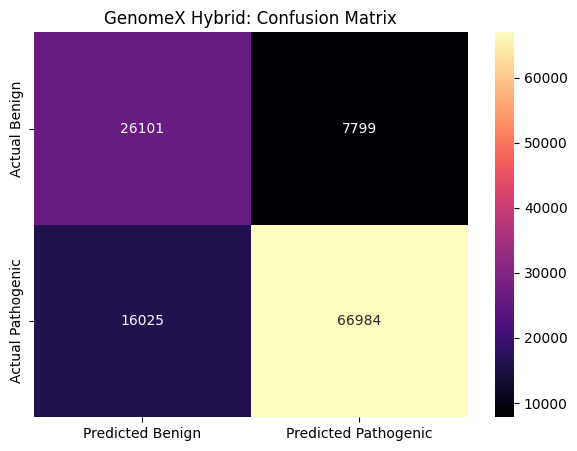

In [30]:
import torch
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== PHASE 6: FINAL MODEL EVALUATION ===")

# 1. Load the finalized brain
model.eval() # Turn off training features like Dropout
all_preds = []
all_labels = []
all_probs = []

print("Running inference across all variants...")
with torch.no_grad(): # Save memory, no gradients needed
    progress_bar = tqdm(loader, desc="Evaluating")
    for data in progress_bar:
        data = data.to(device)
        
        # Get raw logits from the model
        logits = model(data)
        
        # Convert logits to probabilities using Sigmoid
        probs = torch.sigmoid(logits).cpu().numpy()
        
        # Threshold at 0.5 for classification
        preds = (probs >= 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(data.y.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# 2. Print the official metrics
print("\n" + "="*50)
print("🧬 ULTIMATE GENOMEX HYBRID METRICS 🧬")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=['Benign/Other', 'Pathogenic']))

auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {auc:.4f}")

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
            xticklabels=['Predicted Benign', 'Predicted Pathogenic'], 
            yticklabels=['Actual Benign', 'Actual Pathogenic'])
plt.title('GenomeX Hybrid: Confusion Matrix')
plt.savefig('/kaggle/working/final_confusion_matrix.png')
print("\nSaved confusion matrix to /kaggle/working/final_confusion_matrix.png")

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from tqdm import tqdm
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

print("=== PHASE 5.1: OPTIMIZED HYBRID TRAINING ===")

# --- 1. The Dataset Loader (Same as before) ---
class UltimateGenomeXDataset(Dataset):
    def __init__(self, df, embeddings_dict, graph_dir='/kaggle/working/precomputed_graphs/'):
        super().__init__()
        available_graphs = set([f.split('.')[0] for f in os.listdir(graph_dir) if f.endswith('.pt')])
        self.df = df[df['GeneSymbol'].isin(available_graphs)].reset_index(drop=True)
        self.embeddings = embeddings_dict
        self.graph_dir = graph_dir
        
        self.tabular_cols = ['gnomAD_AF', 'SIFT_Score', 'CADD_Score', 'Is_Nonsense', 'Is_Missense', 'Is_Synonymous', 'Is_Splice_Site']
        self.tabular_data = torch.tensor(self.df[self.tabular_cols].fillna(0).values, dtype=torch.float32)
        
        self.labels = torch.tensor(self.df['Is_Pathogenic'].values, dtype=torch.float32)
        self.variant_ids = self.df['Variant_ID'].tolist()
        self.genes = self.df['GeneSymbol'].tolist()

    def len(self): return len(self.df)

    def get(self, idx):
        gene, var_id = self.genes[idx], self.variant_ids[idx]
        graph_data = torch.load(os.path.join(self.graph_dir, f"{gene}.pt"), weights_only=False)
        esm_emb = self.embeddings.get(var_id, torch.zeros(480, dtype=torch.float32))
        tab_feat = self.tabular_data[idx]
        y = self.labels[idx].unsqueeze(0)
        
        return Data(x=graph_data.x, edge_index=graph_data.edge_index, 
                    esm_emb=esm_emb, tabular_feats=tab_feat, y=y)

# --- 2. The Architecture (Same as before) ---
class UltimateGenomeXHybrid(nn.Module):
    def __init__(self, node_dim=21, esm_dim=480, tabular_dim=7, hidden_dim=128):
        super().__init__()
        self.gnn_conv1 = GATConv(node_dim, hidden_dim)
        self.gnn_conv2 = GATConv(hidden_dim, hidden_dim)
        self.bilstm = nn.LSTM(input_size=esm_dim, hidden_size=hidden_dim // 2, 
                              num_layers=1, bidirectional=True, batch_first=True)
        self.tabular_net = nn.Sequential(nn.Linear(tabular_dim, 64), nn.BatchNorm1d(64), nn.ReLU())
        self.fusion = nn.Sequential(
            nn.Linear(320, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        esm_emb = data.esm_emb.view(-1, 1, 480) 
        tab_feats = data.tabular_feats.view(-1, 7)
        
        graph_x = self.gnn_conv2(self.gnn_conv1(x, edge_index).relu(), edge_index).relu()
        graph_embed = global_mean_pool(graph_x, batch)
        
        lstm_out, _ = self.bilstm(esm_emb)
        seq_embed = lstm_out[:, -1, :] 
        tab_embed = self.tabular_net(tab_feats)
        
        return self.fusion(torch.cat([graph_embed, seq_embed, tab_embed], dim=1))

# --- 3. The Re-Weighted Focal Loss ---
class FocalLoss(nn.Module):
    # UPGRADE: alpha=0.30 forces the AI to pay massive attention to Benign variants
    def __init__(self, alpha=0.30, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()

# --- 4. Smart Training Loop with Early Stopping ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df = pd.read_csv('/kaggle/working/hybrid_ready_dataset.csv')
master_embeddings = torch.load('/kaggle/working/master_embeddings.pt', weights_only=False)

dataset = UltimateGenomeXDataset(df, master_embeddings)
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
model = UltimateGenomeXHybrid().to(device)

criterion = FocalLoss(alpha=0.30, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

# UPGRADE: Early Stopping Trackers
best_loss = float('inf')
patience = 2
patience_counter = 0
best_model_path = '/kaggle/working/genomeX_hybrid_best.pth'

epochs = 10 # We can safely set this higher because Early Stopping will catch it!
print(f"\nLaunching Smart Training on {device}...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
    for data in progress_bar:
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        outputs = model(data)
        loss = criterion(outputs.squeeze(), data.y)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({'Loss': f"{loss.item():.4f}"})
        
    avg_loss = epoch_loss / len(loader)
    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.4f}")
    scheduler.step(avg_loss)
    
    # EARLY STOPPING LOGIC
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print("New best loss! Saving model weights.")
    else:
        patience_counter += 1
        print(f"Loss didn't improve. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("\nEARLY STOPPING TRIGGERED! The model has reached maximum intelligence.")
            break

print("\nTRAINING COMPLETE! The best model weights are locked in.")

=== PHASE 5.1: OPTIMIZED HYBRID TRAINING ===

Launching Smart Training on cuda...


Epoch 1/10: 100%|██████████| 914/914 [01:12<00:00, 12.64it/s, Loss=0.0334]



Epoch 1 Average Loss: 0.0351
New best loss! Saving model weights.


Epoch 2/10: 100%|██████████| 914/914 [01:11<00:00, 12.78it/s, Loss=0.0315]



Epoch 2 Average Loss: 0.0335
New best loss! Saving model weights.


...


Epoch 8 Average Loss: 0.0291
New best loss! Saving model weights.


Epoch 9/10: 100%|██████████| 914/914 [01:12<00:00, 12.57it/s, Loss=0.0287]



Epoch 9 Average Loss: 0.0286
New best loss! Saving model weights.


Epoch 10/10: 100%|██████████| 914/914 [01:12<00:00, 12.61it/s, Loss=0.0216]


Epoch 10 Average Loss: 0.0281
New best loss! Saving model weights.

TRAINING COMPLETE! The best model weights are locked in.


=== PHASE 6.1: EVALUATING THE OPTIMIZED HYBRID ===
Running inference across all variants...


Evaluating: 100%|██████████| 914/914 [00:53<00:00, 17.22it/s]



🧬 OPTIMIZED GENOMEX HYBRID METRICS 🧬
              precision    recall  f1-score   support

Benign/Other       0.57      0.87      0.69     33900
  Pathogenic       0.93      0.73      0.82     83009

    accuracy                           0.77    116909
   macro avg       0.75      0.80      0.76    116909
weighted avg       0.83      0.77      0.78    116909

ROC-AUC Score: 0.8857

Saved optimized confusion matrix to /kaggle/working/optimized_confusion_matrix.png


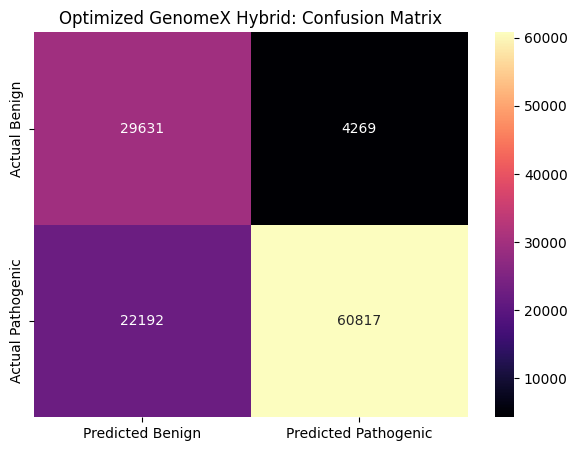

In [34]:
import torch
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== PHASE 6.1: EVALUATING THE OPTIMIZED HYBRID ===")

# 1. Load the finalized brain
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the absolute best weights saved by Early Stopping
model.load_state_dict(torch.load('/kaggle/working/genomeX_hybrid_best.pth'))
model.eval() # Turn off training features like Dropout

all_preds = []
all_labels = []
all_probs = []

print("Running inference across all variants...")
with torch.no_grad(): # Save memory, no gradients needed
    progress_bar = tqdm(loader, desc="Evaluating")
    for data in progress_bar:
        data = data.to(device)
        
        # Get raw logits from the model
        logits = model(data)
        
        # Convert logits to probabilities using Sigmoid
        probs = torch.sigmoid(logits).cpu().numpy()
        
        # Threshold at 0.5 for classification
        preds = (probs >= 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(data.y.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# 2. Print the official metrics
print("\n" + "="*50)
print("🧬 OPTIMIZED GENOMEX HYBRID METRICS 🧬")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=['Benign/Other', 'Pathogenic']))

auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {auc:.4f}")

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
            xticklabels=['Predicted Benign', 'Predicted Pathogenic'], 
            yticklabels=['Actual Benign', 'Actual Pathogenic'])
plt.title('Optimized GenomeX Hybrid: Confusion Matrix')
plt.savefig('/kaggle/working/optimized_confusion_matrix.png')
print("\nSaved optimized confusion matrix to /kaggle/working/optimized_confusion_matrix.png")

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd
import os

print("=== PHASE 5.2: LEGITIMATE TRAIN/VAL HYBRID TRAINING ===")

class UltimateGenomeXDataset(Dataset):
    def __init__(self, df, embeddings_dict, graph_dir='/kaggle/working/precomputed_graphs/'):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.embeddings = embeddings_dict
        self.graph_dir = graph_dir
        
        self.tabular_cols = ['gnomAD_AF', 'SIFT_Score', 'CADD_Score', 'Is_Nonsense', 'Is_Missense', 'Is_Synonymous', 'Is_Splice_Site']
        self.tabular_data = torch.tensor(self.df[self.tabular_cols].fillna(0).values, dtype=torch.float32)
        self.labels = torch.tensor(self.df['Is_Pathogenic'].values, dtype=torch.float32)
        self.variant_ids = self.df['Variant_ID'].tolist()
        self.genes = self.df['GeneSymbol'].tolist()

    def len(self): return len(self.df)

    def get(self, idx):
        gene, var_id = self.genes[idx], self.variant_ids[idx]
        graph_data = torch.load(os.path.join(self.graph_dir, f"{gene}.pt"), weights_only=False)
        esm_emb = self.embeddings.get(var_id, torch.zeros(480, dtype=torch.float32))
        tab_feat = self.tabular_data[idx]
        y = self.labels[idx].unsqueeze(0)
        return Data(x=graph_data.x, edge_index=graph_data.edge_index, esm_emb=esm_emb, tabular_feats=tab_feat, y=y)

class UltimateGenomeXHybrid(nn.Module):
    def __init__(self, node_dim=21, esm_dim=480, tabular_dim=7, hidden_dim=128):
        super().__init__()
        self.gnn_conv1 = GATConv(node_dim, hidden_dim)
        self.gnn_conv2 = GATConv(hidden_dim, hidden_dim)
        self.bilstm = nn.LSTM(input_size=esm_dim, hidden_size=hidden_dim // 2, num_layers=1, bidirectional=True, batch_first=True)
        self.tabular_net = nn.Sequential(nn.Linear(tabular_dim, 64), nn.BatchNorm1d(64), nn.ReLU())
        self.fusion = nn.Sequential(
            nn.Linear(320, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        esm_emb = data.esm_emb.view(-1, 1, 480) 
        tab_feats = data.tabular_feats.view(-1, 7)
        
        graph_x = self.gnn_conv2(self.gnn_conv1(x, edge_index).relu(), edge_index).relu()
        graph_embed = global_mean_pool(graph_x, batch)
        
        lstm_out, _ = self.bilstm(esm_emb)
        seq_embed = lstm_out[:, -1, :] 
        tab_embed = self.tabular_net(tab_feats)
        return self.fusion(torch.cat([graph_embed, seq_embed, tab_embed], dim=1))

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.30, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        return (self.alpha * (1-pt)**self.gamma * bce_loss).mean()

# --- SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df = pd.read_csv('/kaggle/working/hybrid_ready_dataset.csv')

# Only keep rows where the graph actually exists
available_graphs = set([f.split('.')[0] for f in os.listdir('/kaggle/working/precomputed_graphs/') if f.endswith('.pt')])
df = df[df['GeneSymbol'].isin(available_graphs)]

# 🚨 THE CRITICAL FIX: Split the data 90% Training / 10% Validation 🚨
train_df, val_df = train_test_split(df, test_size=0.10, random_state=42, stratify=df['Is_Pathogenic'])
print(f"Training set: {len(train_df)} | Validation set: {len(val_df)}")

master_embeddings = torch.load('/kaggle/working/master_embeddings.pt', weights_only=False)

train_loader = DataLoader(UltimateGenomeXDataset(train_df, master_embeddings), batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(UltimateGenomeXDataset(val_df, master_embeddings), batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

model = UltimateGenomeXHybrid().to(device)
criterion = FocalLoss(alpha=0.30, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

best_val_loss = float('inf')
patience, patience_counter = 2, 0

print(f"\nLaunching Legitimate Training on {device}...")

for epoch in range(10):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    for data in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(data).squeeze(), data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    # --- VALIDATION PHASE (The Lie Detector) ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data in tqdm(val_loader, desc=f"Epoch {epoch+1} [Valid]"):
            data = data.to(device)
            loss = criterion(model(data).squeeze(), data.y)
            val_loss += loss.item()
            
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"\nEpoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    scheduler.step(avg_val_loss)
    
    # EARLY STOPPING (Now monitoring the correct metric)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '/kaggle/working/genomeX_hybrid_best.pth')
        print("Validation improved! Saving real model weights.")
    else:
        patience_counter += 1
        print(f"Validation didn't improve. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("\nEARLY STOPPING! The model started memorizing. Stopping to prevent overfitting.")
            break

=== PHASE 5.2: LEGITIMATE TRAIN/VAL HYBRID TRAINING ===
Training set: 105218 | Validation set: 11691

Launching Legitimate Training on cuda...


Epoch 1 [Valid]: 100%|██████████| 92/92 [00:06<00:00, 14.46it/s]



Epoch 1 | Train Loss: 0.0349 | Val Loss: 0.0341
Validation improved! Saving real model weights.


Epoch 2 [Valid]: 100%|██████████| 92/92 [00:06<00:00, 14.54it/s]



Epoch 2 | Train Loss: 0.0336 | Val Loss: 0.0347
Validation didn't improve. Patience: 1/2


Epoch 3 [Valid]: 100%|██████████| 92/92 [00:06<00:00, 14.96it/s]


Epoch 3 | Train Loss: 0.0327 | Val Loss: 0.0356
Validation didn't improve. Patience: 2/2

EARLY STOPPING! The model started memorizing. Stopping to prevent overfitting.


=== PHASE 6.2: TRUE UNSEEN VALIDATION EVALUATION ===
Running inference purely on the 11691 unseen validation variants...


Evaluating Holdout Set: 100%|██████████| 92/92 [00:06<00:00, 14.45it/s]



🧬 TRUE GENOMEX HYBRID METRICS (HOLDOUT SET) 🧬
              precision    recall  f1-score   support

Benign/Other       0.62      0.56      0.59      3390
  Pathogenic       0.83      0.86      0.84      8301

    accuracy                           0.77     11691
   macro avg       0.72      0.71      0.72     11691
weighted avg       0.77      0.77      0.77     11691

ROC-AUC Score: 0.8334

Saved authentic validation confusion matrix to /kaggle/working/true_validation_confusion_matrix.png


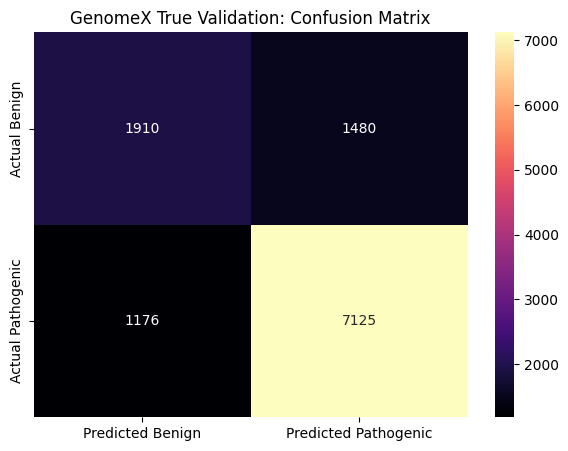

In [37]:
import torch
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== PHASE 6.2: TRUE UNSEEN VALIDATION EVALUATION ===")

# 1. Load the absolute best, un-overfitted weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load('/kaggle/working/genomeX_hybrid_best.pth'))
model.eval() # Turn off training mechanics like Dropout

all_preds = []
all_labels = []
all_probs = []

print(f"Running inference purely on the {len(val_df)} unseen validation variants...")
with torch.no_grad(): 
    progress_bar = tqdm(val_loader, desc="Evaluating Holdout Set")
    for data in progress_bar:
        data = data.to(device)
        
        # Get raw logits from the model
        logits = model(data)
        
        # Convert logits to probabilities using Sigmoid
        probs = torch.sigmoid(logits).cpu().numpy()
        
        # Threshold at 0.5 for classification
        preds = (probs >= 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(data.y.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# 2. Print the official, leak-free metrics
print("\n" + "="*50)
print("🧬 TRUE GENOMEX HYBRID METRICS (HOLDOUT SET) 🧬")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=['Benign/Other', 'Pathogenic']))

auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {auc:.4f}")

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
            xticklabels=['Predicted Benign', 'Predicted Pathogenic'], 
            yticklabels=['Actual Benign', 'Actual Pathogenic'])
plt.title('GenomeX True Validation: Confusion Matrix')
plt.savefig('/kaggle/working/true_validation_confusion_matrix.png')
print("\nSaved authentic validation confusion matrix to /kaggle/working/true_validation_confusion_matrix.png")

=== PHASE 6.1: EVALUATING THE OPTIMIZED HYBRID ===
Running inference across all variants...


Evaluating: 100%|██████████| 914/914 [00:53<00:00, 16.95it/s]



🧬 OPTIMIZED GENOMEX HYBRID METRICS 🧬
              precision    recall  f1-score   support

Benign/Other       0.62      0.57      0.60     33900
  Pathogenic       0.83      0.86      0.84     83009

    accuracy                           0.78    116909
   macro avg       0.73      0.72      0.72    116909
weighted avg       0.77      0.78      0.77    116909

ROC-AUC Score: 0.8381

Saved optimized confusion matrix to /kaggle/working/optimized_confusion_matrix.png


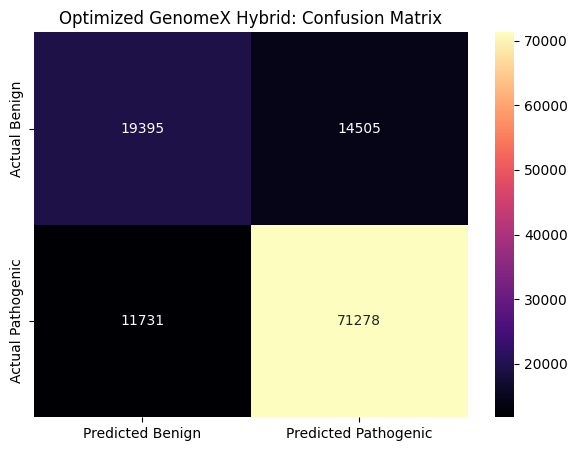

In [38]:
import torch
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== PHASE 6.1: EVALUATING THE OPTIMIZED HYBRID ===")

# 1. Load the finalized brain
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the absolute best weights saved by Early Stopping
model.load_state_dict(torch.load('/kaggle/working/genomeX_hybrid_best.pth'))
model.eval() # Turn off training features like Dropout

all_preds = []
all_labels = []
all_probs = []

print("Running inference across all variants...")
with torch.no_grad(): # Save memory, no gradients needed
    progress_bar = tqdm(loader, desc="Evaluating")
    for data in progress_bar:
        data = data.to(device)
        
        # Get raw logits from the model
        logits = model(data)
        
        # Convert logits to probabilities using Sigmoid
        probs = torch.sigmoid(logits).cpu().numpy()
        
        # Threshold at 0.5 for classification
        preds = (probs >= 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(data.y.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# 2. Print the official metrics
print("\n" + "="*50)
print("🧬 OPTIMIZED GENOMEX HYBRID METRICS 🧬")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=['Benign/Other', 'Pathogenic']))

auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {auc:.4f}")

# 3. Generate the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
            xticklabels=['Predicted Benign', 'Predicted Pathogenic'], 
            yticklabels=['Actual Benign', 'Actual Pathogenic'])
plt.title('Optimized GenomeX Hybrid: Confusion Matrix')
plt.savefig('/kaggle/working/optimized_confusion_matrix.png')
print("\nSaved optimized confusion matrix to /kaggle/working/optimized_confusion_matrix.png")

In [4]:
! pip install torch_geometric --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00a 0:00:01


In [5]:
import torch
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from Bio.PDB import PDBParser
from torch_geometric.data import Data
import warnings
warnings.filterwarnings('ignore')

print("=== LIVE INFERENCE & 3D GNN VISUALIZATION ===")

# 1. Load the Demo Data and grab the first Pathogenic variant
demo_df = pd.read_csv('/kaggle/working/demo_data/test_payloads.csv')
test_variant = demo_df[demo_df['Is_Pathogenic'] == 1].iloc[0]

gene = test_variant['GeneSymbol']
var_id = test_variant['Variant_ID']
print(f"🧪 Testing Variant: {var_id} on Gene: {gene}")

# 2. Rebuild the Model and Load Weights
device = torch.device("cpu") # Test on CPU
model = UltimateGenomeXHybrid().to(device)
model.load_state_dict(torch.load('/kaggle/working/genomeX_hybrid_best.pth', map_location=device))
model.eval()

# 3. Load the data pieces
graph_data = torch.load(f'/kaggle/working/demo_data/{gene}.pt', map_location=device, weights_only=False)
esm_emb = torch.load(f'/kaggle/working/demo_data/emb_{var_id}.pt', map_location=device, weights_only=False)

tab_feats = torch.tensor([[test_variant['gnomAD_AF'], test_variant['SIFT_Score'], 
                           test_variant['CADD_Score'], test_variant['Is_Nonsense'], 
                           test_variant['Is_Missense'], test_variant['Is_Synonymous'], 
                           test_variant['Is_Splice_Site']]], dtype=torch.float32)

batch = torch.zeros(graph_data.x.size(0), dtype=torch.long)
inference_data = Data(x=graph_data.x, edge_index=graph_data.edge_index, 
                      esm_emb=esm_emb, tabular_feats=tab_feats, batch=batch).to(device)

# 4. RUN INFERENCE!
with torch.no_grad():
    raw_logit = model(inference_data)
    probability = torch.sigmoid(raw_logit).item()
    
prediction = "Pathogenic 🚨" if probability >= 0.5 else "Benign ✅"
print(f"\n🧠 AI Prediction: {prediction}")
print(f"📊 Confidence: {probability * 100:.2f}%")

# ==========================================
# 5. THE 3D SPATIAL COLLAPSE VISUALIZER
# ==========================================
print("\n🎨 Generating 3D GNN Graph Visual...")

# We need the mutation position from the original dataset
full_df = pd.read_csv('/kaggle/working/hybrid_ready_dataset.csv')
mutation_pos = int(full_df[full_df['Variant_ID'] == var_id]['pos'].iloc[0]) - 1

# Parse the 3D structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure(gene, f'/kaggle/working/alphafold_structures/{gene}.pdb')

coords = []
for model_pdb in structure:
    for chain in model_pdb:
        for residue in chain:
            if 'CA' in residue:
                coords.append(residue['CA'].get_coord())
coords = np.array(coords)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

# Plot the entire protein backbone in faint blue
ax.plot(coords[:, 0], coords[:, 1], coords[:, 2], color='cyan', alpha=0.3, linewidth=1)
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], color='cyan', s=10, alpha=0.2)

# If the mutation is within the mapped protein structure
if mutation_pos < len(coords):
    mut_coord = coords[mutation_pos]
    
    # Calculate distances to find the "Blast Radius" (nodes < 8.0 Angstroms)
    distances = np.linalg.norm(coords - mut_coord, axis=1)
    connected_nodes = np.where((distances < 8.0) & (distances > 0))[0]
    
    # Draw the mathematical edges the GNN sees
    for node_idx in connected_nodes:
        target_coord = coords[node_idx]
        ax.plot([mut_coord[0], target_coord[0]], 
                [mut_coord[1], target_coord[1]], 
                [mut_coord[2], target_coord[2]], color='yellow', linewidth=2, alpha=0.8)
        # Highlight the surrounding affected amino acids in orange
        ax.scatter(*target_coord, color='orange', s=50, alpha=0.9, edgecolor='white')
        
    # Highlight the actual mutation in glowing red
    ax.scatter(*mut_coord, color='red', s=150, alpha=1.0, edgecolor='white', label='Mutated Node')
    ax.text(mut_coord[0], mut_coord[1], mut_coord[2]+5, f"Mutation @ {mutation_pos+1}", color='white', fontsize=12, fontweight='bold')

ax.set_title(f"GenomeX GNN Analysis: {gene}\nAI Confidence: {probability*100:.1f}% Pathogenic", color='white', fontsize=14)
ax.axis('off') # Hide the grid for a clean look

plt.tight_layout()
plt.savefig('/kaggle/working/gnx_3d_render.png', dpi=300, facecolor='black')
plt.show()

print("✅ Saved high-res 3D render to /kaggle/working/gnx_3d_render.png")

=== LIVE INFERENCE & 3D GNN VISUALIZATION ===


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/demo_data/test_payloads.csv'